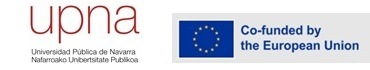

<div style="text-align:center"; font-size: 20px;>
    
# Geospatial Data Analysis

</div>

**Author:** Naziru Halilu


## TOPIC 7: Sentinel-1 download and processing

### 1. Import libraries

We import the libraries that will be used in this first data download process.
The Copernicus Data Space Ecosystem (CDSE) provides a wide range of APIs, each designed for different types of operations and access levels.
For data downloading, we will use the OData API (Open Data Protocol), which allows direct access to Sentinel products and metadata.

More information about OData:
https://dataspace.copernicus.eu/news/2023-9-28-accessing-sentinel-mission-data-new-copernicus-data-space-ecosystem-apis

1. **File handling and operating system utilities**:
   - `os` for managing file paths and directories.  
   - `getpass` for securely entering your username and password without displaying them.  
   - `warnings` to suppress unnecessary warnings during execution.

2. **API requests and web access**:
   - `requests` for sending HTTP requests to the CDSE APIs.  
   - `urllib.parse.quote` to safely encode URL parameters such as bounding boxes.

3. **Data handling and geospatial operations**:
   - `pandas` for handling tabular data like search results and product metadata.  
   - `geopandas` for reading and manipulating vector files (GeoJSON or Shapefiles) representing the AOI.

By importing these libraries, we set up the environment needed for querying CDSE APIs, handling spatial and tabular data, and downloading Sentinel products efficiently.

In [ ]:
import os            # Operating system utilities (e.g., file paths)
import requests      # For HTTP requests (API calls)
import pandas as pd  # For handling tables (metadata, search results)
import geopandas as gpd  # For reading GeoJSON/Shapefiles (AOI)
import getpass       # For securely entering username/password
from urllib.parse import quote  # to safely encode URL parameters

In [ ]:
import warnings
warnings.filterwarnings('ignore')

### 2. Create functions

#### 2.1. Function to create folders

In [ ]:
import errno
def createdir(path):
    os.makedirs(path, exist_ok=True)

#### 2.2. Function to authenticate and get acceess token
Function to request an access token from the CDSE identity server. Input parameters: CDSE username and password. The token is required to authenticate subsequent API requests.

In [ ]:
def get_access_token(username: str, password: str) -> str:
    """
    Requests an access token from Copernicus Data Space Ecosystem (CDSE)
    using user credentials.
    """
    # Parameters required by the identity endpoint
    data = {
        "client_id": "cdse-public",     # Public client ID (no special privileges)
        "username": username,           # CDSE username (email)
        "password": password,           # CDSE password
        "grant_type": "password",       # Type of authentication flow
    }
    # Identity endpoint URL (OAuth2)
    url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    # Send POST request to obtain the access token
    r = requests.post(url, data=data)
    # Check if the request succeeded (status 200 = OK)
    if r.status_code != 200:
        raise RuntimeError(f"Access token creation failed: {r.status_code} - {r.text}")
    # Extract the token string from the JSON response
    js = r.json()
    return js.get("access_token", "")

#### 2.3. Function to search for available Sentinel-1 products
Once authenticated, we can search for Sentinel-1 products available in the CDSE catalogue. Here we use the RESTO API, which allows us to filter products by:

- collection name (e.g., Sentinel1)

- time period

- bounding box (longitude/latitude)

- sensor mode, orbit direction, and other metadata filters.

The function below builds a query URL, sends it to the catalogue,
and returns the results in JSON format.

MORE INFO. about the API: https://dataspace.copernicus.eu/analyse/apis/catalogue-apis

In [ ]:
def CDSE_query(collection='', start_date='', end_date='', bbox='',
             sensorMode='', productType='', orbitDirection='', relativeOrbitNumber=''):
    """
    Queries the CDSE catalogue for products that meet the specified filters.
    """
    # Base URL for RESTO API (product catalogue)
    base = f'https://catalogue.dataspace.copernicus.eu/resto/api/collections/{collection}/search.json'

    # Build the main part of the query
    query = (
        f'?startDate={start_date}T00:00:00Z'           # Start of the search period
        f'&completionDate={end_date}T23:59:59Z'        # End of the search period
        f'&box={quote(bbox)}'                          # Bounding box: lon_min,lat_min,lon_max,lat_max
        f'&sortParam=startDate&sortOrder=descending'   # Sort results by start date (newest first)
    )

    # Add optional filters only if they are provided
    if sensorMode: query += f'&sensorMode={sensorMode}'
    if productType: query += f'&productType={productType}'
    if orbitDirection: query += f'&orbitDirection={orbitDirection}'
    if relativeOrbitNumber: query += f'&relativeOrbitNumber={relativeOrbitNumber}'

    # Send GET request to the catalogue
    r = requests.get(base + query)
    r.raise_for_status()  # stop if request failed (e.g., wrong dates or bbox)

    # Return the response JSON (list of matching products)
    return r.json()

#### 2.4. Convert JSON results into a DataFrame
The **JSON** response from the CDSE API is not very human-readable. To make it easier to work with, we convert it into a **pandas DataFrame**. Each row will correspond to one Sentinel-1 product, and each column to useful metadata (title, dates, orbit, UUID, etc.).

In [ ]:
#Función para convertir el json de consulta en un df
def json_to_df(json_data, keys=['title', 'startDate', 'completionDate', 'orbitDirection', 'relativeOrbitNumber']):
    feats = json_data.get('features', [])  # List of products in the JSON
    records = []
    # Loop over each product (feature) and extract useful information
    for f in feats:
        props = f.get('properties', {})      # product metadata
        rec = {k: props.get(k) for k in keys}
        rec['uuid'] = f.get('id')            # unique product identifier
        records.append(rec)
    # Convert list of dictionaries to DataFrame
    return pd.DataFrame(records).sort_values('startDate', ascending=False)

#### 2.5. Download Sentinel-1 products
Once we have identified the product(s) we want to download,we can use the **OData API (zipper service)** to download them as `.zip` files. Each ZIP contains the `.SAFE` structure of a Sentinel product. 

The function below handles authentication, streaming, and saving to disk.

In [ ]:
def download(name, uuid, access_token):
    # Build the OData download URL for the product
    url = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({uuid})/$value"
    # Add the Bearer token to the request header for authentication
    headers = {"Authorization": f"Bearer {access_token}"} # Asks for the access to the CDSE
    # Stream the response and write to file
    with requests.get(url, headers=headers, stream=True) as response:
        if response.status_code != 200:
            raise RuntimeError(f"Error {r.status_code}: {r.text}")
        # Save to disk
        with open(name, "wb") as f:
            for chunk in response.iter_content(8192): # It just reads 8 KB per iteration
                if chunk:
                    f.write(chunk)

Once the functions that will be used in this first section are defined, we set the directory where the files required for the practical session are stored. In this case, the setup assumes that the folder named **Topic_7** is located on the desktop.

In [ ]:
# Define the folder path where the dataset is located
DIR_PATH = r'C:\Users\alumno\Desktop\Topic_7' # Use raw string (r'') to avoid issues with backslashes

To download images using the **OData API**, it is necessary to know the unique identifier (**UUID**) of each product. Therefore, the process is divided into two stages:

1. In the first stage, a query is performed to list the available images that meet the desired specifications (time period, study area, orbit direction, etc.), from which the product UUIDs are obtained.

2. The second stage consists of downloading the selected products.

### 3. Query of available products and extraction of the UUID

#### 3.1. Define search parameters
To perform a search, we first need to define different search parameters. The parameters shown below should **always be set** to optimize and narrow the query:

- **aoi (Area of Interest)**: the study area. The script can read different types of vector files (`.shp`, `.geojson`, etc.). It is recommended to define simple geometries (squares or rectangles). At the end, a bounding box will be generated from the AOI.  
  Coordinate system: WGS84 (EPSG:4326).
- **collection**: name of the image collection. In our case: `'Sentinel-1'` (it could also be used with `'Sentinel-2'`).  
- **start_date** and **end_date**: time range for the query. Date format: `'YYYY-MM-DD'`.  
- **bbox**: the script is prepared to convert the vector AOI file into coordinates for the bounding box.  

If you want to refine the search further, you can define **four additional optional parameters**:

- **sensorMode**: acquisition mode of the sensor (`'IW'`, `'SM'`, `'EW'`, `'WV'`).  
- **orbitDirection**: orbit direction (`'ASCENDING'` or `'DESCENDING'`).  
- **productType**: type of product (`'GRD'`, `'RAW'`, `'SLC'`, `'OCN'`).  
- **relativeOrbitNumber**: relative orbit number.

We define the search parameters here. In the next cell, we can adjust these values according to the specific query we want to perform.


In this example, we work with a predefined study area stored in a GeoJSON file.
Using GeoPandas, we can read the file and extract its bounding box (min/max coordinates).

The bounding box will later be passed to the search query as a `bbox` parameter.

In [ ]:
SHP_PATH = os.path.join(DIR_PATH,'00-AUX','00-shps','AOI.geojson')
aoi = gpd.read_file(SHP_PATH)
aoi_bounds = aoi.geometry.bounds
aoi_bounds

In [ ]:
collection = 'Sentinel1'             # product collection
start_date = '2023-11-01'            # search start date (YYYY-MM-DD)
end_date = '2023-11-22'              # search end date (YYYY-MM-DD)
# Create a string with the bounding box coordinates
bbox = '{},{},{},{}'.format(
    str(aoi_bounds['minx'][0]),
    str(aoi_bounds['miny'][0]),
    str(aoi_bounds['maxx'][0]),
    str(aoi_bounds['maxy'][0])
)
# Optional filters (recommended for Sentinel-1 GRD)
sensorMode = 'IW'                    # Interferometric Wide Swath
orbitDirection = 'ASCENDING'         # Sensing direction: ASCENDING or DESCENDING
productType = 'GRD'                  # Ground Range Detected (GRD) or Single Look Complex (SLC)
relativeOrbitNumber = 103            # relative orbit number (optional)

#### Define the Area of Interest (AOI)

#### 3.2. Query the catalogue and inspect results
We perform the search using the `CDSE_query()` function. There is **no need to change anything** in the following part of the code.

In [ ]:
json = CDSE_query(collection = collection,
              start_date = start_date,end_date = end_date,
              bbox = bbox,
              sensorMode = sensorMode, orbitDirection = orbitDirection,
              productType = productType, relativeOrbitNumber = str(relativeOrbitNumber))
json

We convert the JSON file obtained from the query into a **pandas DataFrame**. This allows us to **visualize the results more clearly** and work with them more easily.

In [ ]:
df = json_to_df(json)
df

### 5. Authenticate and download images

To download products, it is necessary to be registered in the **Copernicus Data Space Ecosystem (CDSE)**. We will connect by entering our CDSE username (email) and password in the next cell. There are **two ways** to do this:

1. `access_token = get_access_token("username", "password")`:  
   You must replace `"username"` with your CDSE email and `"password"` with your CDSE password.

2. Using the interactive method (no changes needed):  
   Simply execute the cell, and it will prompt you to enter your email and password securely.

**IMPORTANT**: Add a `#` in front of the lines for the option you do **not** want to use.

In [ ]:
#1)
#access_token = get_access_token("username", "password") # Replace "username" with your CDSE email and "password" with your CDSE passowrd
#2)
access_token = get_access_token(
    getpass.getpass("CDSE username (email): "), # Do NOT replace anything here
    getpass.getpass("CDSE password: "), # Do NOT replace anything here
)

In the next cell, we can define the **number of images** we want to download.  
For this practical example, we will set it to **1**, since downloading each product takes approximately **5 minutes**.  

To download **all available images**, simply leave the field empty (`''`).

In [ ]:
nimgs = 4  # set number of images to download; use '' to download all
# Select subset of the DataFrame
dfD = df[:nimgs] if isinstance(nimgs, int) else df.copy()
# Define local folder to save images
DWNLD_IMGS_PATH = os.path.join(DIR_PATH, '01-Dwnld_imgs')
createdir(DWNLD_IMGS_PATH)
# Loop through the selected products and download them
for uuid, title in zip(dfD['uuid'], dfD['title']):
    nombre = os.path.join(DWNLD_IMGS_PATH, title + '.zip')
    print(f"Downloading {title} ...")
    download(nombre, uuid, access_token)

### 6. Processing Sentinel-1 images

Once the images have been downloaded, we can also automate the processing process. To do this, we will first import the libraries that we will use in this section:

   - **`glob`**: used to find files an didrectories whose names match a specified pattern. It supports wildcards like `*`,`?`, and character ranges.   
   - **`rasterio`**: A library for reading and writing geospatial raster data (e.g., satellite images). It helps to handle geospatial data formats like GeoTIFF and is essential for performing operations on raster datasets, such as image processing, clipping, or extracting pixel values.

   - **`numpy`**: A core library for numerical computing in Python. It provides support for large, multi-dimensional arrays and matrices, as well as a variety of mathematical functions to operate on them. In this context, `numpy` is typically used for performing pixel-level operations on raster images.

   - **`datetime`**: This module allows for working with dates and times in Python. It can be used to manipulate timestamps (e.g., for image acquisition dates) and format date-related data efficiently, which is often important when dealing with satellite data or time series analysis.

   - **`matplotlib.pyplot`**: A widely-used plotting library in Python, particularly useful for creating visualizations like graphs, histograms, and images. It is essential for displaying the results of image processing, such as visualizing raster layers, histograms of pixel values, or plots of time-series data.

   - **`xml.etree.ElementTree`**: A built-in library used to parse and create XML data. It is particularly useful when working with metadata or configuration files, which are often in XML format. This library can be used to extract specific information from XML files, such as image metadata or file headers.


By importing these libraries, we set up the necessary tools for processing geospatial raster data, manipulating numerical data, working with dates, visualizing results, and extracting information from XML metadata. This combination of libraries is essential for automating image processing workflows and analyzing satellite imagery in Python.


In [ ]:
import glob
import rasterio
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET 

We establish the two paths of interest:

- `DWNLD_IMGS_PATH`: The path where the downloaded images are located. For this practical session, we will set the path to the folder `01-Already_Dwnld_imgs` to save time on downloading. However, if you want to test this code with the images downloaded in the previous section, you should comment the DWNLD_IMGS_PATH line.

- `PROC_IMGS_PATH`: The path where the processed images will be stored.

In [ ]:
#Definimos y creamos el directorio donde se almacenarán las imagenes procesadas
DWNLD_IMGS_PATH = os.path.join(DIR_PATH,'01-Already_Dwnld_imgs')
PROC_IMGS_PATH = os.path.join(DIR_PATH,'02-Proc_imgs')
createdir(PROC_IMGS_PATH)

We also define the paths for the `.xml` files obtained using SNAP's Graph Builder, which will be used for processing. In this case, since the study area is located between two acquisitions of the same relative orbit, two separate files are provided for two different cases:

In [ ]:
#Definimos la ruta donde está el archivo xml que contiene el procesado de las imágenes
DOUBLE_XML_PATH = os.path.join(DIR_PATH,'00-AUX','00-gpt','SNAP_S1_double_processing.xml')
SINGLE_XML_PATH = os.path.join(DIR_PATH,'00-AUX','00-gpt','SNAP_S1_single_processing.xml')

With this new cell, we modify the subset of the `.xml` file to match the defined study area. An erro will occur if it is unable to modify the XML file, and a message will apprar warning you to make the modification manually in SNAP.

**Before executing this cell, open the `.xml`file.**

In [ ]:
try:
    if gpd.read_file(SHP_PATH).geom_type[0] == 'MultiPolygon': shp = str(gpd.read_file(SHP_PATH).explode().iloc[0].geometry)
    else: shp = shp = str(gpd.read_file(SHP_PATH).iloc[0].geometry)
    for XML_PATH in [DOUBLE_XML_PATH,SINGLE_XML_PATH]:
        tree = ET.parse(XML_PATH)
        root = tree.getroot()
        root.find('.//geoRegion').text = shp
        tree.write(XML_PATH)
    del shp, XML_PATH
except: print('The .xml files could not be modified. Please make the changes manually in SNAP.')

The next step is to store the file paths of the downloaded images that we want to process.

In [ ]:
images = glob.glob(os.path.join(DWNLD_IMGS_PATH,'*S1*.zip'))
print('Number of images:',len(images))
dates = set([os.path.basename(image).split('_')[4].split('T')[0] for image in images])
print('Number of aqcuisition dates:',len(dates))

In this step, we create a dictionary where each **key** represents an acquisition date, and each **value** is an empty list that will later store the image paths corresponding to that date. This structure will allow us to easily group, access, and process all images acquired on the same date.

In [ ]:
images_by_date = {date:[] for date in dates}
'''
images_by_date = {}
for date in dates:
    images_by_date[date] = []
'''
images_by_date

Now that we have a dictionary where each key is a date, we loop through all downloaded images and assign each one to the correct date entry.

In [ ]:
for image in images:
    date = os.path.basename(image).split('_')[4].split('T')[0]
    images_by_date[date].append(image)
images_by_date

In [ ]:
for date, img_list in images_by_date.items():
    print(f"\nDate: {date} → {len(img_list)} image(s)")
    print(img_list)

#### Processing images grouped by acquisition date

In this step, we loop through the dictionary `images_by_date`, where each key is an acquisition date and each value is the list of images belonging to that date. Depending on whether a date contains **one** or **two** images, we will process them using the appropriate SNAP GPT workflow (single-image or paired-image processing).

In [ ]:
for date, img_list in images_by_date.items():
    print(f"\nDate: {date} → {len(img_list)} image(s)")

    # Define the path for the final directories
    img_date_path = os.path.join(PROC_IMGS_PATH,date)
    createdir(img_date_path)
    # Define the 'base' path of the outputs
    path_base_name = os.path.join(img_date_path,'S1_'+date)
    #Define the complete path for the final outputs
    VH_path = path_base_name + '_VH_dB.tif'
    VV_path = path_base_name + '_VV_dB.tif'
    VHVV_path = path_base_name + '_Ratio_dB.tif'
    
    if len(img_list) == 2:
        print(" → Processing as paired images ...")
        image1,image2 = img_list[0],img_list[1]
        os.system(r'cd C:\Program Files\snap\bin & gpt ' + DOUBLE_XML_PATH + ' -Pinput1=' + image1 + ' -Pinput2=' + image2
            + ' -Ptarget1=' + VH_path + ' -Ptarget2=' + VV_path + ' -Ptarget3=' + VHVV_path)
        del image1, image2
    elif len(img_list) == 1:
        print(" → Processing as a single image ...")
        image = img_list[0]
        os.system(r'cd C:\Program Files\snap\bin & gpt ' + SINGLE_XML_PATH + ' -Pinput1=' + image
            + ' -Ptarget1=' + VH_path + ' -Ptarget2=' + VV_path + ' -Ptarget3=' + VHVV_path)
        del image
    else:
        print(" → Unnexpected number of images per acquisition. Please review it.")
    del date, img_list,img_date_path,path_base_name,VH_path,VV_path,VHVV_path
print('** Processing completed')

We can now compute the vegetation indices using the **VV** and **VH** backscatter bands from Sentinel-1 imagery. Remember that both VH and VV have been saved in decibels, so we need to convert them to linear units if we want to make operations between bands. 

In [ ]:
# Define a function to 
def _dB_to_linear_(raster):
    return 10**(raster/10)
def _RVI_(VH,VV):
    return (4*VH)/(VV+VH)

In [ ]:
VH_imgs_path = glob.glob(os.path.join(PROC_IMGS_PATH,'*','*_VH_*'))
VV_imgs_path = glob.glob(os.path.join(PROC_IMGS_PATH,'*','*_VV_*'))
VV_imgs_path

In [ ]:
for vh_path,vv_path in zip(VH_imgs_path,VV_imgs_path):
    # Open the rasters
    VH_raster = rasterio.open(vh_path).read(1)
    VV_raster = rasterio.open(vv_path).read(1)
    
    # Convert the rasters to linear units
    VH_raster_linear = _dB_to_linear_(VH_raster)
    VV_raster_linear = _dB_to_linear_(VV_raster)
    # Calculate the Radar Vegetation Index
    RVI = _RVI_(VH_raster_linear,VV_raster_linear)
    # Save the raster
    folder_raster_path = os.path.dirname(vv_path)
    # Extract raster metadat
    metadata = rasterio.open(vv_path)
    transform = metadata.transform
    dtype = VH_raster.dtype
    crs = metadata.crs
    rvi_path = os.path.join(folder_raster_path,os.path.basename(vv_path).replace('VV_dB','RVI'))
    print('Saving',os.path.basename(rvi_path),'file')
    with rasterio.open(rvi_path,'w',height = VH_raster.shape[0],width = VH_raster.shape[1],count = 1, 
                       dtype = dtype,crs = crs, transform = transform) as dst:
                            dst.write(RVI,1)
    

#### Visualizing the processed images

If an error occurred during the download or processing of Sentinel-1 images, we can still continue the practical exercise by loading **previously processed images**. This section explains how to read those images and prepare them for visualization.


In [ ]:
# To continue the practical exercise, if any error occurred during the download or processing,
# you can activate the following line in order to load and visualize an already processed image.
# PROC_IMGS_PATH = os.path.join(DIR_PATH,'02-Already_proc_imgs')  # Activate only if processing failed

In [ ]:
# Select the acquisition date you want to visualize
date = '20231118'  # This is the date you may modify

In [ ]:
# Read the processed images using rasterio and store them in the list 'images'
path_imgs_vis = glob.glob(os.path.join(PROC_IMGS_PATH,date,'*.tif')) # List of full paths of the images to visualize
images = [rasterio.open(path_img_vis).read(1) for path_img_vis in path_imgs_vis] # List of images read as arrays
'''
images = []
for for path_img_vis in path_imgs_vis:
    images.append(rasterio.open(path_img_vis).read(1))
'''
images

In [ ]:
# Do the same to extract the band names (band_names)
band_names = [os.path.basename(path_img_vis).split('_')[2] for path_img_vis in path_imgs_vis] #Lista con los nombres y fechas de las imágenes leídas en el punto anterior
'''
nimgs = []
for path_img_vis in path_imgs_vis:
    nimgs.append(os.path.basename(path_img_vis).split('_')[2])
'''
band_names = [n.split('.')[0] for n in band_names]
band_names

In this step, we create a dictionary where each **key** is the name of a processed band (e.g., `VH_dB`, `VV_dB`, `Ratio_dB`) and each **value** is the corresponding raster image stored as a NumPy array. This will make it much easier to access and visualize each band individually.

In [ ]:
dict_images = {band:image for band,image in zip(band_names,images)}
'''
dict_images = {}
for band,image in zip(band_names,images):
    dict_images[band] = image
del band,image
'''
dict_images

Once we have our data organized, we create a figure to display all processed bands (VH, VV, and VH/VV ratio) for the selected acquisition date. Each band is shown in grayscale with its own colorbar for easier interpretation.

In [ ]:
fig = plt.figure(1, figsize=(10,15))
for i, (band, raster) in enumerate(dict_images.items()):
    # Each band is plotted in its own subplot
    ax = fig.add_subplot(len(band_names), 1, i + 1)
    
    # Display the raster image in grayscale
    pos = plt.imshow(raster, cmap=plt.cm.gray)
    
    # Adjust the title (formatting the Ratio band)
    plt.title(band.replace('Ratio', 'Ratio (VH/VV)'))
    
    # Add a colorbar next to each subplot
    fig.colorbar(pos, ax=ax, location='right', anchor=(0, 0.3), shrink=0.7)

# Add a global title using a YYYY/MM/DD format
plt.suptitle(date[:4] + '/' + date[4:6] + '/' + date[6:])
# Improve spacing between subplots
plt.tight_layout()
plt.show()

In addition to displaying the raster images, it is often useful to inspect the **distribution of pixel values**. This helps us understand the radiometric behaviour of each band and detect issues such as noise, saturation, or outliers. The following code generates a histogram for each processed band (VH, VV, Ratio).

In [ ]:
%matplotlib inline
fig = plt.figure(1, figsize=(5,10))
for i, (band, raster) in enumerate(dict_images.items()):
    ax = fig.add_subplot(len(band_names), 1, i + 1)
    
    # Flatten the 2D raster into a 1D array for histogram computation
    plt.hist(raster.flatten(), bins=50)
    
    plt.title(band)

# Global title using YYYY/MM/DD format
plt.suptitle(date[:4] + '/' + date[4:6] + '/' + date[6:])
plt.tight_layout()
plt.show()

Processed SAR bands often have values in **dB** or other ranges that do not match the scales `matplotlib` uses to display images.  If we try to plot them directly, some pixels may appear completely white or completely black, losing contrast.  

Therefore, before creating an RGB image, we need to **rescale** (normalize) each band to a suitable range, usually between **0 and 1**.  The following function allows us to do this using three different methods:

In [ ]:
# Function to scale an image
def colorscale(x, scale = 'percentile'):
    if scale ==  'MinMax':
        return((x - np.nanmin(x))/(np.nanmax(x) - np.nanmin(x)))
    if scale ==  'percentile':
        return((x - np.nanpercentile(x, 2))/(np.nanpercentile(x, 98) - np.nanpercentile(x,2)))
    if scale == 'Std':
        return((x - (np.nanmean(x)-np.nanstd(x)*2))/((np.nanmean(x)+np.nanstd(x)*2) - (np.nanmean(x)-np.nanstd(x)*2)))

To visualize a combination of bands (e.g., VH, VV, Ratio), we need to stack them into a single 3-channel image using `np.dstack`.

In [ ]:
red,green,blue = 'VV','VH','VV' # Bands to assign to R, G, B channels
color_scale = 'Std' # Choose from: 'MinMax', 'percentile', 'Std'
# Rescale each selected band
red_stretched = np.clip(colorscale(dict_images[red], color_scale),0,1)
green_stretched = np.clip(colorscale(dict_images[green], color_scale),0,1)
blue_stretched = np.clip(colorscale(dict_images[blue], color_scale),0,1)

In [ ]:
%matplotlib notebook

# Stack bands into an RGB image
# rgb = np.dstack((dict_images[red],dict_images[green],dict_images[blue]))
rgb = np.dstack((red_stretched,green_stretched,blue_stretched))
# Display the RGB composite
plt.imshow(rgb)
plt.title(f'RGB ({red},{green},{blue}) from '+date[:4]+'/'+date[4:6]+'/'+date[6:])
plt.show()

### 7. Time series analysis

#### 7.1. Qualitative analysis

In [ ]:
pip install animatplot

The next step is to **analyze the time series of the acquired images** for different land-cover types. As in the previous sections, we will start by importing the necessary Python libraries.

1. **General-purpose operations**:
   - `time`: to manage time-related operations, such as pauses or measuring execution time.  
   - `IPython.display`: for controlling the display of outputs, animations, and updates in Jupyter notebooks.

2. **Visualization**:
   - `matplotlib.ticker`: to customize axis ticks and formatting in plots.  
   - `animatplot`: for creating animations of time series data, showing changes over time.

3. **Spatial analysis**:
   - `rasterstats`: to calculate statistics of raster values within vector zones (zonal statistics), e.g., computing mean or sum of pixel values for a given AOI.

In [ ]:
import time               # Time-related functions (delays, measuring execution time)
import numpy as np        # Numerical operations and array manipulations
import pandas as pd       # Table-like data structures and data analysis
import geopandas as gpd   # Handling geospatial vector data (AOIs, polygons)
from IPython import display  # Display control in Jupyter notebooks

import animatplot as amp  # Create animations for time series data
import matplotlib.ticker as ticker  # Customize plot axis ticks and formatting

First, we will **visualize the time series**, both for individual bands (selecting the ones we want) and for RGB composites that we define. For this, we will use the **animatplot** library, which allows us to create animated plots and save them as GIFs.  

**IMPORTANT:** You must include the line `%matplotlib notebook` in each cell where you want to display the animated plot. If you later want to display a static plot, you should replace it with `%matplotlib inline`.  

We will define two directories:

- `PROC_IMGS_PATH`: path where the images to be analyzed are stored.  
- `GIFS_PATH`: path where the generated GIFs will be saved.

In [ ]:
# Define and create the directory where the GIFs will be stored
PROC_IMGS_PATH = os.path.join(DIR_PATH,'02-Already_proc_imgs')   # Path to the processed images to be analyzed
GIFS_PATH = os.path.join(DIR_PATH, '03-gifs')                    # Path where the generated GIFs will be saved
createdir(GIFS_PATH)                                               # Create the GIF directory if it does not exist

In the next cell, we can choose the band we want to visualize. **Important:** the band name must match the filename exactly.

In [ ]:
band = 'VH'  # Select the band we want to visualize

In [ ]:
# Get a list of all image paths matching the selected band, excluding auxiliary files
img_ts_path = glob.glob(os.path.join(PROC_IMGS_PATH, '*', f'*_{band}_*'))
img_ts_path

In [ ]:
# Read each raster image into a list (only the first band/layer), skipping auxiliary files
imgs_ts = []
for path_image in img_ts_path:
    imgs_ts.append(rasterio.open(path_image).read(1))
imgs_ts

In [ ]:
# Extract filenames and remove the 'S1_' prefix to get dates
dates = []
for path_image in img_ts_path:
    dates.append(os.path.basename(path_image).split('_')[1])
dates

In [ ]:
# Create titles for the plots with band name and formatted date
titles = []
for date in dates:
    titles.append(f'Band {band} from {date[:4]}/{date[4:6]}/{date[6:]}')
titles    

When visualizing a series of satellite images, it is important to **scale the pixel values** for better contrast and easier interpretation. Raw radar values often have a wide range, and without scaling, differences between dates or bands can be hard to see.

- If each image is scaled independently, the relative differences between dates may be distorted.  
- This allows us to accurately observe **temporal changes** in the area of interest and understand real variations in backscatter or indices, rather than differences caused by scaling.

We can use different scaling methods, such as:

- **Min-Max scaling**: linearly maps the values to [0,1] using the global minimum and maximum.  
- **Percentile scaling**: focuses on the 2nd to 98th percentiles to reduce the effect of extreme outliers.  
- **Standard deviation scaling**: maps values to a range defined by ±2 standard deviations around the mean, highlighting typical variations.

By applying the same scaling to all images in the time series, we ensure **consistent visualization and meaningful comparison**.

In [ ]:
# Function to scale a list of images (improves visualization and contrast)
def colorscale_ST(lista, scale='percentile'):
    if scale == 'MinMax': 
        # Compute the global min and max across all images
        minval, maxval = np.nanmin([x.min() for x in lista]), np.nanmax([x.max() for x in lista])
        # Scale each image to the range [0,1] using min-max normalization
        return [(x - minval) / (maxval - minval) for x in lista]
    else:
        # Flatten all images into a single list for percentile or std-based scaling
        flatlist = [i for x in lista for i in x.flatten()]
        if scale == 'percentile':
            # Compute the 2nd and 98th percentiles
            percentile_a, percentile_b = np.nanpercentile(flatlist, 2), np.nanpercentile(flatlist, 98)
            # Scale each image based on these percentiles
            return [(x - percentile_a) / (percentile_b - percentile_a) for x in lista]
        if scale == 'Std':
            # Compute mean and standard deviation across all images
            meanval, stdval = np.nanmean(flatlist), np.nanstd(flatlist)
            # Scale each image to ±2 standard deviations around the mean
            return [(x - (meanval - stdval*2)) / ((meanval + stdval*2) - (meanval - stdval*2)) for x in lista]


In [ ]:
color_scale = 'percentile'  # Choose scaling method: 'MinMax', 'percentile', 'Std'
scaled_imgs_ts = colorscale_ST(imgs_ts, scale=color_scale)
scaled_imgs_ts

In the next cell, we will **visualize a GIF** showing the time series images for the selected band.

In [ ]:
nimgs_s = 1  # Define the number of images per second to display

# Define the timeline: número de frames y velocidad (fps)
timeline = amp.Timeline(np.arange(len(scaled_imgs_ts)), fps=1, units = 's')
vmin, vmax = min([np.min(x) for x in scaled_imgs_ts]), max([np.max(x) for x in scaled_imgs_ts]) # Determine global min and max for consistent scaling

In [ ]:
timeline

In [ ]:
%matplotlib notebook
# Create an image block
imgs_block = amp.blocks.Imshow(
    scaled_imgs_ts,
    cmap=plt.cm.gray,
    vmin=vmin,
    vmax=vmax)

# Define the titles per each image
title_block = amp.blocks.Title(titles)

# Define the timeline: number of frames per second
timeline = amp.Timeline(np.arange(len(scaled_imgs_ts)), fps=1)
# Create the animation with image blocks and timeline
anim = amp.Animation([imgs_block, title_block], timeline)
# Controles completos: play/pause + slider
anim.controls()
# Guardar como GIF
anim.save_gif(os.path.join(GIFS_PATH, f'TimeSeries_{band}'))

# Mostrar la animación
plt.show()

Let's now visualize the temporal series of a RGB composite

In [ ]:
red, green, blue = 'VV', 'VH', 'VV'# Define the RGB composition (Red, Green, Blue bands)
nimgs_s = 1                        # Number of images per second to display
color_scale = 'Std'                # Define the color scaling method to apply

In [ ]:
# Get lists of file paths for each band
red_imgs_path = glob.glob(os.path.join(PROC_IMGS_PATH,'*',f'*_{red}_*'))
green_imgs_path = glob.glob(os.path.join(PROC_IMGS_PATH,'*',f'*_{green}_*'))
blue_imgs_path = glob.glob(os.path.join(PROC_IMGS_PATH,'*',f'*_{blue}_*'))
red_imgs_path

In [ ]:
# Read each raster image into a list (first band/layer)
red_imgs = [rasterio.open(red_path).read(1) for red_path in red_imgs_path]
'''
red_imgs = []
for red_path in red_imgs_path:
    red_imgs.append(rasterio.open(red_path).read(1))
'''
green_imgs = [rasterio.open(green_path).read(1) for green_path in green_imgs_path]
blue_imgs = [rasterio.open(blue_path).read(1) for blue_path in blue_imgs_path]
red_imgs

In [ ]:
# Extract dates from filenames of the Red band images
dates = [os.path.basename(path).split('_')[1] for path in red_imgs_path] 
dates

In [ ]:
# Create titles for the RGB composite plots including the bands and formatted date
titles = [f'RGB Composite ({red},{green},{blue})\n' + x[:4] + '/' + x[4:6] + '/' + x[6:] for x in dates]
titles

In [ ]:
# Stack the R, G, B images into RGB composites and apply consistent scaling
ts_imgs_rgb = []
for red_raster, green_raster, blue_raster in zip(red_imgs,green_imgs,blue_imgs):
    red_raster_scaled = np.clip(colorscale_ST(red_raster, scale=color_scale),0,1)
    green_raster_scaled = np.clip(colorscale_ST(green_raster, scale=color_scale),0,1)
    blue_raster_scaled = np.clip(colorscale_ST(blue_raster, scale=color_scale),0,1)
    rgb_stack = np.dstack((red_raster_scaled,green_raster_scaled,blue_raster_scaled))
    ts_imgs_rgb.append(rgb_stack)
ts_imgs_rgb

Visualize the results:

In [ ]:
nimgs_s = 1
# Create a timeline for the animation based on the number of images
timeline = amp.Timeline(np.arange(len(scaled_imgs_ts)), fps=nimgs_s)

# Determine global min and max values across all RGB images for consistent scaling
vmin, vmax = min([np.min(x) for x in ts_imgs_rgb]), max([np.max(x) for x in ts_imgs_rgb])

In [ ]:
%matplotlib notebook
# Create an image block
imgs_block = amp.blocks.Imshow(
    ts_imgs_rgb, vmin=vmin, vmax=vmax)

# Define the titles per each image
title_block = amp.blocks.Title(titles)

# Define the timeline: number of frames per second
timeline = amp.Timeline(np.arange(len(scaled_imgs_ts)), fps=1)
# Create the animation with image blocks and timeline
anim = amp.Animation([imgs_block, title_block], timeline)
# Controles completos: play/pause + slider
anim.controls()
# Guardar como GIF
anim.save_gif(os.path.join(GIFS_PATH, f'TimeSeries_{band}'))

# Mostrar la animación
plt.show()

#### 7.2. Cuantitative analysis

In [ ]:
pip install rasterstats

In [ ]:
from rasterstats import zonal_stats

The next step is to analyze the time series of different land cover types using plots. We will do this by extracting zonal statistics from various parcels with different uses, which are stored in the vector file `LandUses.geojson`.

In [ ]:
land_uses = gpd.read_file(os.path.join(DIR_PATH,'00-AUX','00-shps','LandUses.geojson')).sort_values(by='id').reset_index(drop = True)
land_uses

Once the zones are defined in the shapefile, we extract the zonal statistics using the `rasterstats` library. The input parameters are:

- `shp`: the shapefile containing the parcels defined in the previous step.
- `ruta_imgs_st[i]`: the full path to the raster from which we want to extract the statistics.
- `stats`: the statistics we want to extract.


In [ ]:
# Define the directory where the CSV files with the time series data will be stored
CSV_PTH = os.path.join(DIR_PATH,'04-SeriesTemporales_csv')
createdir(CSV_PTH)

# Define the metrics we want to calculate
metrics = ['mean']

In [ ]:
# Extract zonal statistics for each band and date, combining them into a single DataFrame
for band in band_names: 
    print('Extracting statistics for', band)
    
    # Select the images corresponding to the current band
    ts_imgs_path = glob.glob(os.path.join(PROC_IMGS_PATH,'*','*_'+band+'*')) 

    # Create the DataFrame to which we will add the extracted data
    df = pd.DataFrame(index=range(len(land_uses))).join(land_uses['LandUse'])
    
    # Extract zonal statistics for each date
    for img_path in ts_imgs_path:
        fecha = os.path.basename(img_path).split('_')[1]  # Extract the date from the folder name
        
        # Compute zonal statistics
        stats = zonal_stats(land_uses, img_path, nodata=np.nan, stats=metrics)
        
        # Store the results in a DataFrame for exporting later
        df_stats = pd.DataFrame(stats)
        df0 = land_uses.join(df_stats)[metrics]
        df0.columns = [fecha]
        df = df.join(df0)
    
    # Export the DataFrame to a CSV file
    print('Saving the csv file')
    df.to_csv(os.path.join(CSV_PTH,'TimeSeries_'+band+'.csv'), index=False)

Finally, we will plot the results of the time series. We will do this in two ways:

1. **Time series by band:** For each band individually, we will plot the results for all land use types.
2. **Time series by land use:** For each land use type individually, we will plot the results for all bands.

##### Time series by band

In [ ]:
# Select specific land uses to display
selected_uses = ['Agri_area','Flooded_agri_area'] #
# Options: ['Water', 'Forest', 'Agri_area', 'Asphalt', 'Urban_area',Flooded_agri_area', 'Burned_forest']

In [ ]:
%matplotlib inline
# Create a figure with a specific size
fig = plt.figure(figsize=(7, 20))
for i,band in enumerate(band_names): 
    # Read the time series CSV for the current band
    df = pd.read_csv(os.path.join(CSV_PTH,'TimeSeries_'+band+'.csv'))
    
    # Set 'LandUse' (land use) as index and transpose to have dates as rows
    dfplot = df.set_index('LandUse').T
    
    # Filter only the desired land uses
    if len(selected_uses) > 0: 
        dfplot = dfplot[[landuse for landuse in dfplot.columns if landuse in selected_uses]]
        
    # Plot each band in a separate subplot
    ax = fig.add_subplot(7, 1, i+1)
    dfplot.plot(ax = ax)
    
    ax.set_title('Time series of band '+band)
    ax.set_ylabel(band)
    
    # Customize x-axis with formatted dates
    ax.xaxis.set_ticks(np.arange(0,len(dfplot)))
    ax.set_xticklabels([(x[:4].replace('20','')+'/'+x[4:6]+'/'+x[6:]) for x in dfplot.index], rotation = 90)
    
    # Remove individual subplot legends
    ax.get_legend().remove()
# Add a common legend above all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=5)
fig.tight_layout()

##### Time series by land use

In [ ]:
#Select specific land use
selected_land_use = 'Agri_area'

In [ ]:
# Get all CSV files with time series
csv_files = glob.glob(os.path.join(CSV_PTH, 'TimeSeries_*.csv'))
csv_files

In [ ]:
# Initialize a DataFrame to store all bands for the selected land use
df_land_use = pd.DataFrame()

In [ ]:
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    df = df.loc[df['LandUse'] == selected_land_use]  # Filter for the selected land use
    
    # Extract the band name from the file name
    file_name = os.path.basename(csv_file)
    band_name = file_name.split('_')[-1].split('.')[0]
    
    # Replace the 'LandUse' value with the band name
    df.iloc[0, 0] = band_name
    
    # Transpose the DataFrame so that dates are rows and bands are columns
    df = df.set_index('LandUse').T
    
    # Merge with the main DataFrame
    df_land_use = df.copy() if df_land_use.shape == (0, 0) else df_land_use.join(df)
df_land_use

In [ ]:
# Plot the results
%matplotlib inline

fig, ax = plt.subplots(figsize=(12, 5))

df_land_use.plot(ax=ax)

# Customize x-axis
ax.set_xticks(np.arange(len(df_land_use)))
ax.set_xticklabels([f"{x[:4]}/{x[4:6]}/{x[6:]}" for x in df_land_use.index], rotation=90)

# Set labels and title
ax.set_ylabel('Decibels (dB)')
ax.set_title(f'Time Series of a {selected_land_use}')

# Add legend
ax.legend(loc='center right', bbox_to_anchor=(1.15, 0.5))

fig.tight_layout()
